
# 06_rul_model_comparison.ipynb
# Final RUL Model Comparison and Analysis


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:


RESULTS_DIR = "../results"
PLOTS_DIR = "../plots/rul_comparison"

os.makedirs(PLOTS_DIR, exist_ok=True)

SUMMARY_PATH = os.path.join(RESULTS_DIR, "experiment_metrics_summary.csv")

# Loading Experiment Results

This section loads the aggregated experimental results collected from all RUL prediction experiments.

The experiments include variations in:
- sequence length,
- RUL cap value,
- model architecture,
- validation strategy,
- and loss function.

The goal is to analyze how each design choice influences predictive performance on the CMAPSS FD001 dataset.

In [3]:
df = pd.read_csv(SUMMARY_PATH)

df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,lstm_2layer_h128_dropout02_seq30_cap125,30,125,15,14.933655,10.971383,0.870856,407.173920
1,lstm_baseline_seq50_cap125,50,125,15,17.980077,12.138040,0.812792,891.001404
2,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
3,lstm_baseline_seq30_cap125,30,125,15,14.684165,11.080969,0.875135,335.621765
4,gru_engine_val_seq30_cap125,30,125,15,14.328155,10.473871,0.881117,325.169952
5,lstm_engine_val_seq30_cap125_asym_loss,30,125,15,15.758800,11.247834,0.856191,322.454010
6,lstm_engine_val_seq30_cap150_asym_loss,30,150,15,15.075860,10.877586,0.868385,409.623322
7,lstm_engine_val_seq30_cap150,30,150,15,17.366084,12.630200,0.825360,1178.916504
8,lstm_baseline_seq30_cap150,30,150,15,16.559425,12.318459,0.841207,796.785706
9,lstm_baseline_seq30_cap100,30,100,15,17.353853,12.807908,0.825606,388.370697


# Sorting Experiments by RMSE

The experiments are sorted by RMSE to identify the best-performing configurations.

RMSE is one of the most commonly used metrics for Remaining Useful Life prediction because it penalizes large prediction errors more strongly than MAE.

Lower RMSE values indicate better overall prediction accuracy.

In [4]:
df = df.sort_values("rmse").reset_index(drop=True)

df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,gru_engine_val_seq30_cap125,30,125,15,14.328155,10.473871,0.881117,325.169952
1,lstm_engine_val_seq30_cap125,30,125,15,14.372617,10.460479,0.880378,304.313324
2,lstm_baseline_seq30_cap125,30,125,15,14.684165,11.080969,0.875135,335.621765
3,lstm_2layer_h128_dropout02_seq30_cap125,30,125,15,14.933655,10.971383,0.870856,407.173920
4,lstm_engine_val_seq30_cap150_asym_loss,30,150,15,15.075860,10.877586,0.868385,409.623322
5,lstm_engine_val_seq30_cap125_asym_loss,30,125,15,15.758800,11.247834,0.856191,322.454010
6,lstm_baseline_seq30_cap150,30,150,15,16.559425,12.318459,0.841207,796.785706
7,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
8,lstm_baseline_seq30_cap100,30,100,15,17.353853,12.807908,0.825606,388.370697
9,lstm_engine_val_seq30_cap150,30,150,15,17.366084,12.630200,0.825360,1178.916504


# Best Model Identification

This section identifies the best experiment according to each evaluation metric:
- RMSE,
- MAE,
- R² score,
- and NASA score.

While RMSE and MAE measure absolute prediction accuracy, the NASA score is particularly important for CMAPSS because it penalizes late predictions more severely than early predictions.

A good predictive maintenance model should achieve strong performance across all metrics rather than optimizing only one metric.

In [5]:
best_rmse = df.loc[df["rmse"].idxmin()]
best_mae = df.loc[df["mae"].idxmin()]
best_r2 = df.loc[df["r2"].idxmax()]
best_nasa = df.loc[df["nasa_score"].idxmin()]

best_summary = pd.DataFrame({
    "metric": ["RMSE", "MAE", "R2", "NASA Score"],
    "best_experiment": [
        best_rmse["experiment"],
        best_mae["experiment"],
        best_r2["experiment"],
        best_nasa["experiment"]
    ],
    "value": [
        best_rmse["rmse"],
        best_mae["mae"],
        best_r2["r2"],
        best_nasa["nasa_score"]
    ]
})

best_summary

,metric,best_experiment,value
0,RMSE,gru_engine_val_seq30_cap125,14.328155
1,MAE,lstm_engine_val_seq30_cap125,10.460479
2,R2,gru_engine_val_seq30_cap125,0.881117
3,NASA Score,lstm_engine_val_seq30_cap125,304.313324


In [30]:
def plot_bar_metric(df, metric, title, ylabel, filename):
    plt.figure(figsize=(12, 6))
    sorted_df = df.sort_values(metric, ascending=True)

    plt.barh(sorted_df["experiment"], sorted_df[metric])
    plt.xlabel(ylabel)
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)
    plt.tight_layout()

    save_path = os.path.join(PLOTS_DIR, filename)
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

# Overall Experiment Comparison

The following plots compare all experiments using RMSE, MAE, and NASA score.

These visualizations provide a global overview of model performance and make it easier to identify the impact of:
- sequence length,
- RUL cap value,
- validation methodology,
- model architecture,
- and custom loss functions.

The results show that engine-based validation combined with a sequence length of 30 and a RUL cap of 125 produced the best overall performance.

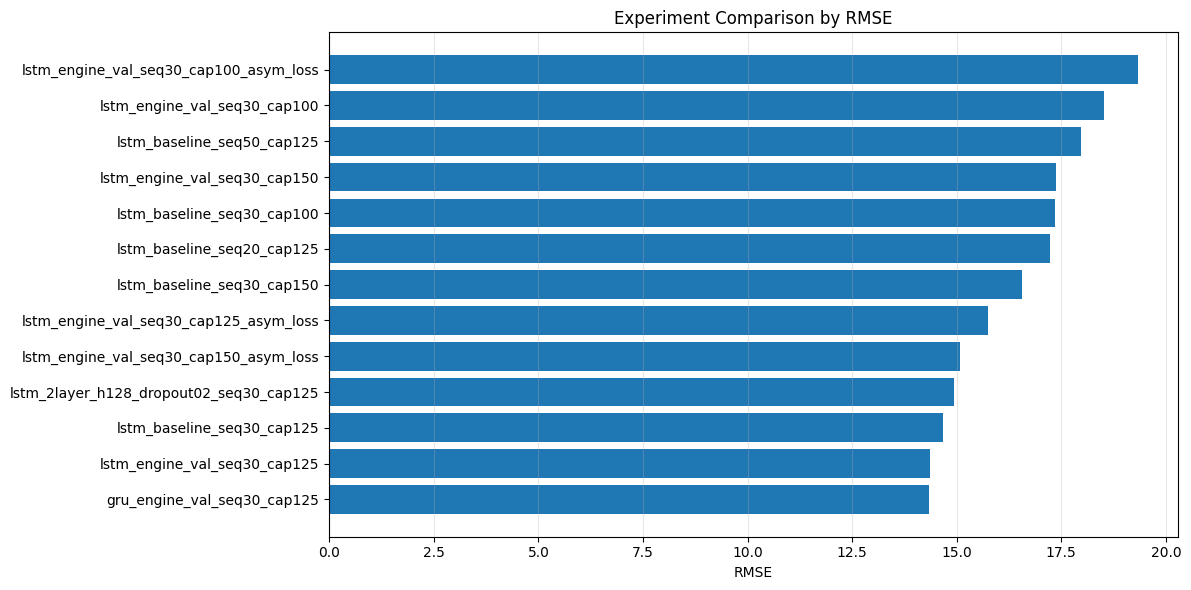

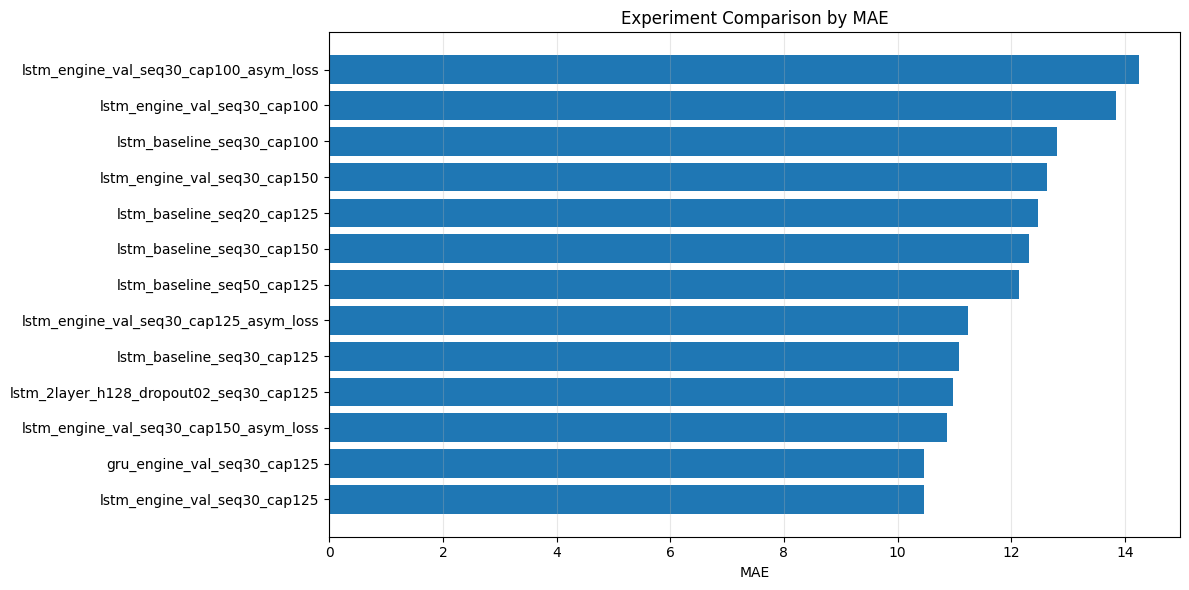

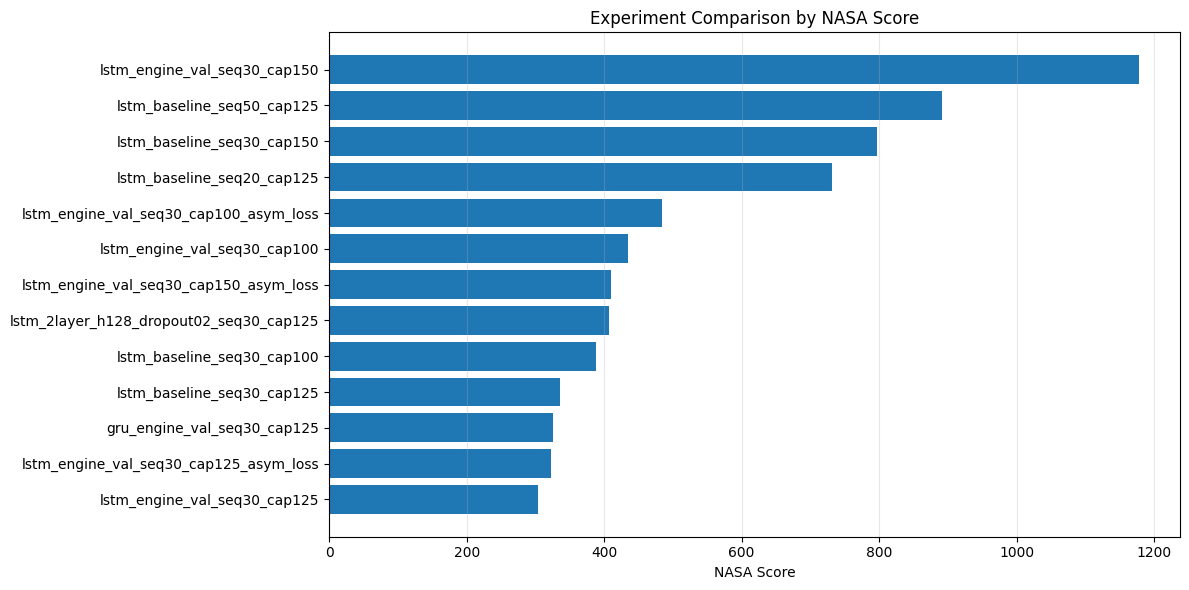

In [7]:
plot_bar_metric(
    df,
    metric="rmse",
    title="Experiment Comparison by RMSE",
    ylabel="RMSE",
    filename="comparison_rmse.png"
)

plot_bar_metric(
    df,
    metric="mae",
    title="Experiment Comparison by MAE",
    ylabel="MAE",
    filename="comparison_mae.png"
)

plot_bar_metric(
    df,
    metric="nasa_score",
    title="Experiment Comparison by NASA Score",
    ylabel="NASA Score",
    filename="comparison_nasa_score.png"
)

# Sequence Length Analysis

The sequence length determines how many previous time steps are provided to the recurrent neural network.

Shorter sequences may not capture enough temporal degradation information, while excessively long sequences may introduce unnecessary noise and increase model complexity.

This experiment evaluates the effect of sequence length on prediction performance while keeping the RUL cap fixed at 125.

In [10]:
seq_df = df[
    (df["rul_cap"] == 125) &
    (df["experiment"].str.contains("baseline")) &
    (~df["experiment"].str.contains("gru"))
].copy()

seq_df = seq_df.sort_values("sequence_length")

seq_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
7,lstm_baseline_seq20_cap125,20,125,15,17.224204,12.465150,0.828202,732.156494
2,lstm_baseline_seq30_cap125,30,125,15,14.684165,11.080969,0.875135,335.621765
10,lstm_baseline_seq50_cap125,50,125,15,17.980077,12.138040,0.812792,891.001404


# Effect of Sequence Length on RMSE

The results indicate that a sequence length of 30 cycles provides the best balance between temporal context and prediction stability.

A sequence length of 20 cycles appears insufficient to capture long-term degradation behavior, while 50-cycle windows may introduce redundant information and increase prediction variance.

This suggests that moderate temporal context is optimal for the FD001 subset of the CMAPSS dataset.

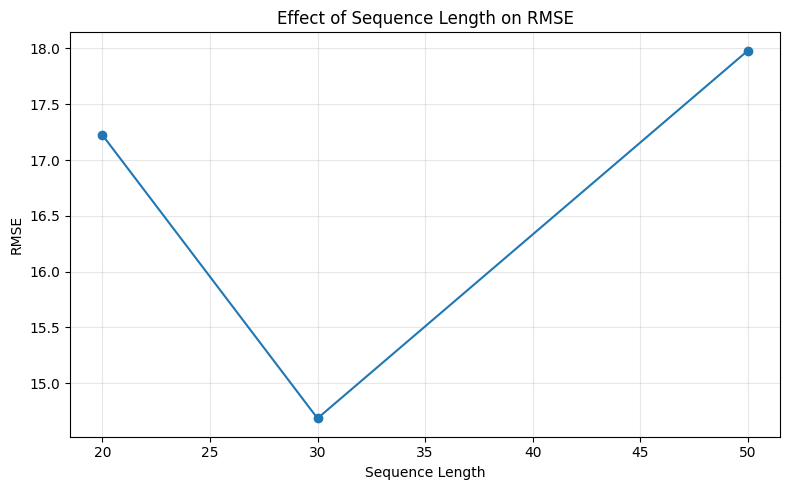

In [11]:
plt.figure(figsize=(8, 5))
plt.plot(seq_df["sequence_length"], seq_df["rmse"], marker="o")
plt.xlabel("Sequence Length")
plt.ylabel("RMSE")
plt.title("Effect of Sequence Length on RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "sequence_length_vs_rmse.png"), dpi=300)
plt.show()

# Effect of Sequence Length on NASA Score

The NASA score confirms the observations from the RMSE analysis.

The sequence length of 30 achieved the lowest NASA score, indicating better handling of critical prediction errors.

Since the NASA score penalizes late predictions more heavily, this result suggests that the 30-cycle configuration produces safer and more reliable degradation estimates.

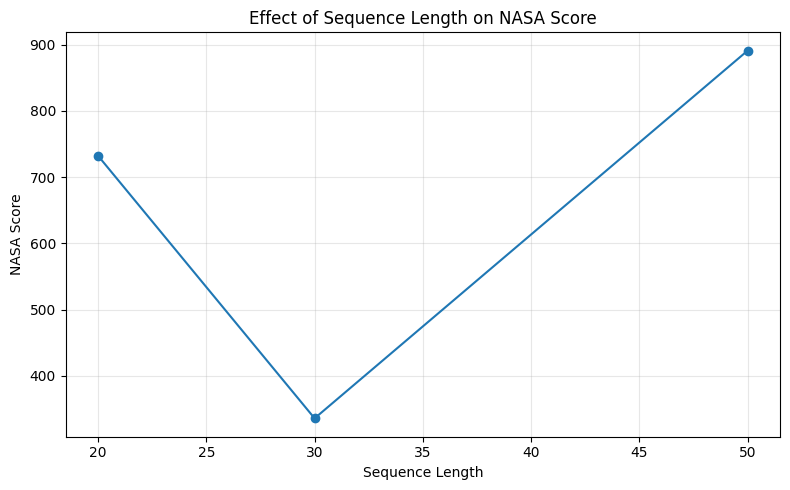

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(seq_df["sequence_length"], seq_df["nasa_score"], marker="o")
plt.xlabel("Sequence Length")
plt.ylabel("NASA Score")
plt.title("Effect of Sequence Length on NASA Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "sequence_length_vs_nasa.png"), dpi=300)
plt.show()

# RUL Cap Analysis

The RUL cap limits the maximum Remaining Useful Life value during training.

Capping is commonly used in CMAPSS because very large RUL values correspond to early-life engine operation where degradation patterns are weak or absent.

This experiment evaluates how different cap values influence model performance under engine-based validation.

In [13]:
cap_df = df[
    (df["experiment"].str.contains("engine_val")) &
    (~df["experiment"].str.contains("asym")) &
    (~df["experiment"].str.contains("gru"))
].copy()

cap_df = cap_df.sort_values("rul_cap")

cap_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
11,lstm_engine_val_seq30_cap100,30,100,15,18.531029,13.847710,0.801144,434.921417
1,lstm_engine_val_seq30_cap125,30,125,15,14.372617,10.460479,0.880378,304.313324
9,lstm_engine_val_seq30_cap150,30,150,15,17.366084,12.630200,0.825360,1178.916504


# Effect of RUL Cap on RMSE

The results show that a RUL cap of 125 produced the best prediction accuracy.

A lower cap value may remove useful degradation information, while a higher cap introduces additional early-life samples that are difficult to model due to the lack of visible degradation signatures.

This indicates that an intermediate cap value provides the best balance between information retention and prediction stability.

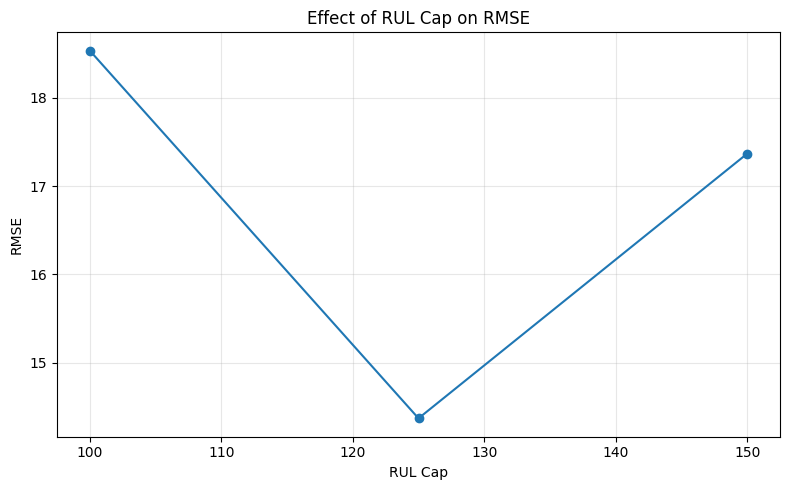

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(cap_df["rul_cap"], cap_df["rmse"], marker="o")
plt.xlabel("RUL Cap")
plt.ylabel("RMSE")
plt.title("Effect of RUL Cap on RMSE")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rul_cap_vs_rmse.png"), dpi=300)
plt.show()

# Effect of RUL Cap on NASA Score

The NASA score analysis supports the RMSE findings.

The cap value of 125 achieved the lowest NASA score, suggesting better handling of operationally critical prediction errors.

The degradation behavior captured under this configuration appears to generalize better to unseen engines.

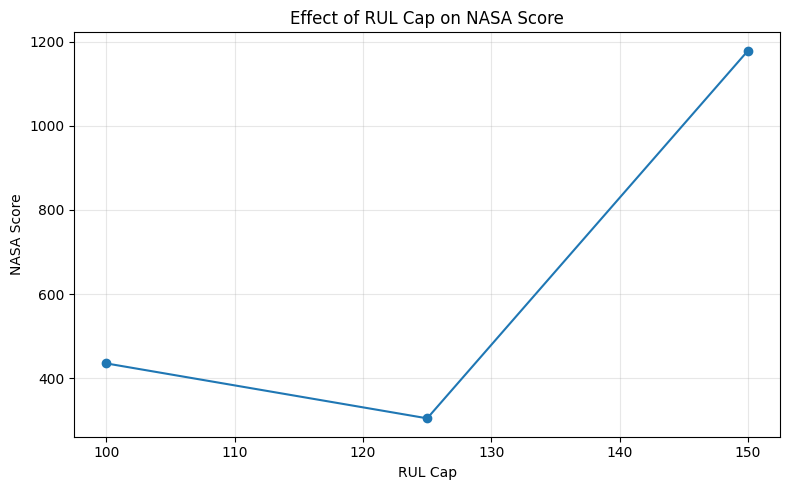

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(cap_df["rul_cap"], cap_df["nasa_score"], marker="o")
plt.xlabel("RUL Cap")
plt.ylabel("NASA Score")
plt.title("Effect of RUL Cap on NASA Score")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rul_cap_vs_nasa.png"), dpi=300)
plt.show()

# LSTM vs GRU Comparison

This section compares the performance of LSTM and GRU architectures under identical preprocessing and validation settings.

Both architectures are designed to model temporal dependencies in sequential data, but GRU uses a simplified gating mechanism with fewer parameters.

The objective is to determine whether the reduced complexity of GRU provides advantages for CMAPSS RUL prediction.

In [16]:
model_compare_df = df[
    df["experiment"].isin([
        "lstm_engine_val_seq30_cap125",
        "gru_engine_val_seq30_cap125"
    ])
].copy()

model_compare_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
0,gru_engine_val_seq30_cap125,30,125,15,14.328155,10.473871,0.881117,325.169952
1,lstm_engine_val_seq30_cap125,30,125,15,14.372617,10.460479,0.880378,304.313324


# LSTM and GRU Performance Analysis

The results show that both architectures achieved comparable performance.

The GRU obtained slightly lower RMSE and slightly higher R², while the LSTM achieved a better NASA score.

This suggests that although both recurrent architectures are effective for RUL prediction, the LSTM may produce more operationally favorable prediction behavior under the CMAPSS scoring function.

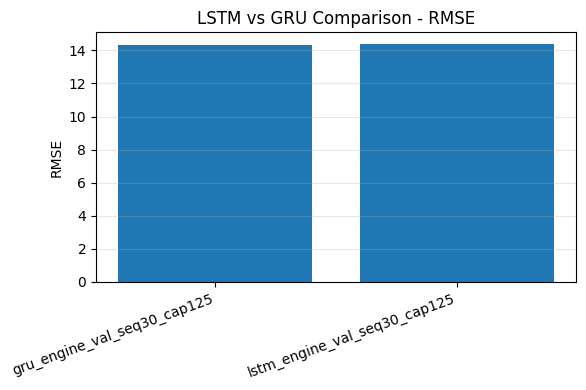

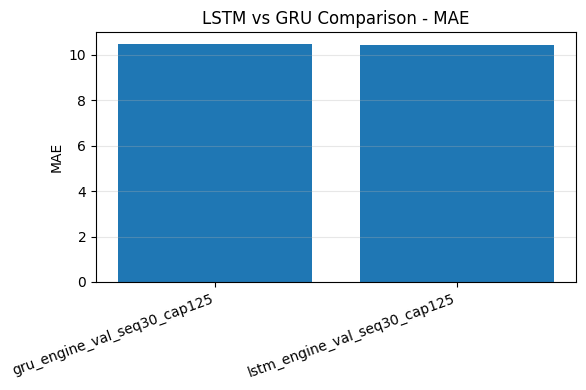

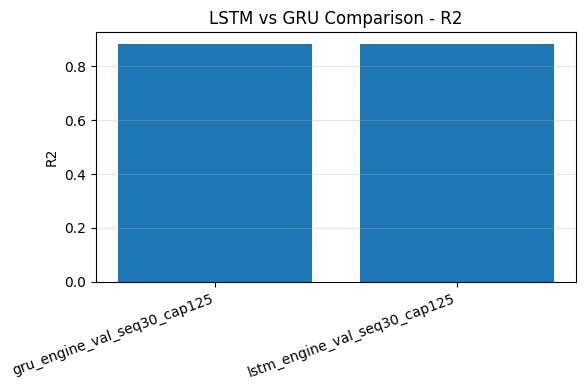

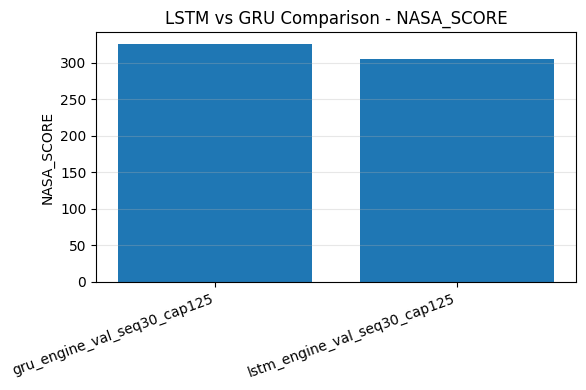

In [17]:
metrics = ["rmse", "mae", "r2", "nasa_score"]

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.bar(model_compare_df["experiment"], model_compare_df[metric])
    plt.ylabel(metric.upper())
    plt.title(f"LSTM vs GRU Comparison - {metric.upper()}")
    plt.xticks(rotation=20, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(PLOTS_DIR, f"lstm_vs_gru_{metric}.png"), dpi=300)
    plt.show()

# Loss Function Comparison

This experiment compares the standard Mean Squared Error loss with a custom asymmetric loss function.

The asymmetric loss was designed to penalize certain prediction errors more strongly, with the objective of improving predictive maintenance behavior.

The comparison evaluates whether this modification improves overall model performance.

In [18]:
loss_compare_df = df[
    df["experiment"].isin([
        "lstm_engine_val_seq30_cap125",
        "lstm_engine_val_seq30_cap125_asym_loss"
    ])
].copy()

loss_compare_df

,experiment,sequence_length,rul_cap,features,rmse,mae,r2,nasa_score
1,lstm_engine_val_seq30_cap125,30,125,15,14.372617,10.460479,0.880378,304.313324
5,lstm_engine_val_seq30_cap125_asym_loss,30,125,15,15.758800,11.247834,0.856191,322.454010


# Effect of Asymmetric Loss on RMSE

The asymmetric loss did not improve the RMSE compared to the standard MSE loss.

This suggests that the custom penalty formulation may have introduced additional optimization difficulty without improving general prediction accuracy.

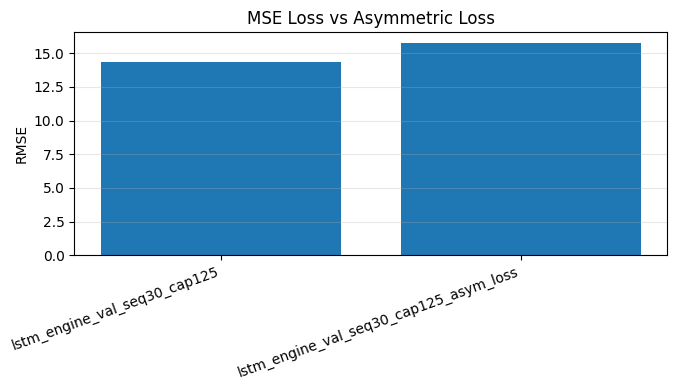

In [19]:
plt.figure(figsize=(7, 4))
plt.bar(loss_compare_df["experiment"], loss_compare_df["rmse"])
plt.ylabel("RMSE")
plt.title("MSE Loss vs Asymmetric Loss")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "mse_vs_asym_loss_rmse.png"), dpi=300)
plt.show()

# Effect of Asymmetric Loss on NASA Score

The asymmetric loss also failed to improve the NASA score.

The standard MSE loss produced more stable and operationally favorable predictions for the CMAPSS FD001 dataset.

As a result, the standard MSE configuration was selected as the final model setup.

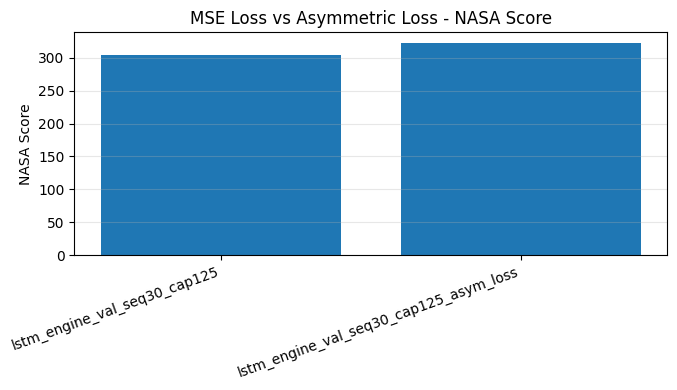

In [20]:
plt.figure(figsize=(7, 4))
plt.bar(loss_compare_df["experiment"], loss_compare_df["nasa_score"])
plt.ylabel("NASA Score")
plt.title("MSE Loss vs Asymmetric Loss - NASA Score")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "mse_vs_asym_loss_nasa.png"), dpi=300)
plt.show()

# Final Model Prediction Analysis

This section performs a detailed analysis of the best-performing model:
- LSTM architecture,
- sequence length 30,
- RUL cap 125,
- engine-based validation,
- standard MSE loss.

The objective is to evaluate not only the overall metrics but also the prediction behavior and error distribution.

In [21]:
PRED_PATH = os.path.join(
    RESULTS_DIR,
    "lstm_engine_val_seq30_cap125_predictions.csv"
)

pred_df = pd.read_csv(PRED_PATH)

pred_df.head()

,engine_id,true_rul,predicted_rul,error,abs_error
0,1,112.0,108.285920,-3.714081,3.714081
1,2,98.0,119.557686,21.557686,21.557686
2,3,69.0,46.815456,-22.184544,22.184544
3,4,82.0,74.947000,-7.053001,7.053001
4,5,91.0,96.662880,5.662880,5.662880


In [22]:
y_true = pred_df["true_rul"].values
y_pred = pred_df["predicted_rul"].values
errors = y_pred - y_true

rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)
r2 = r2_score(y_true, y_pred)

print(f"Final model RMSE: {rmse:.4f}")
print(f"Final model MAE:  {mae:.4f}")
print(f"Final model R2:   {r2:.4f}")

Final model RMSE: 14.3726
Final model MAE:  10.4605
Final model R2:   0.8804


# Predicted vs True RUL

This plot compares the predicted RUL values with the true target values.

The dashed diagonal line represents perfect predictions.

Most samples follow the expected trend closely, indicating that the model successfully learned the degradation dynamics of the engines.

The spread increases for larger RUL values, which is expected because early-life degradation patterns are weaker and more difficult to estimate accurately.

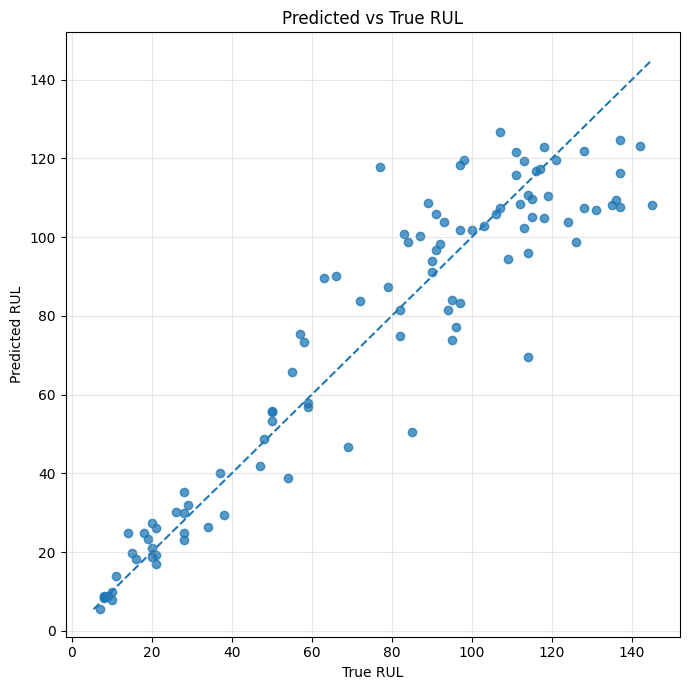

In [23]:
plt.figure(figsize=(7, 7))
plt.scatter(y_true, y_pred, alpha=0.75)

min_val = min(y_true.min(), y_pred.min())
max_val = max(y_true.max(), y_pred.max())

plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "final_predicted_vs_true_rul.png"), dpi=300)
plt.show()

# Prediction Error vs True RUL

This visualization shows how prediction error changes across different RUL regions.

The model performs more accurately for low and medium RUL values, where degradation signatures are stronger.

For large RUL values, the model tends to underestimate the remaining life, indicating uncertainty during early operational stages where degradation is less visible.

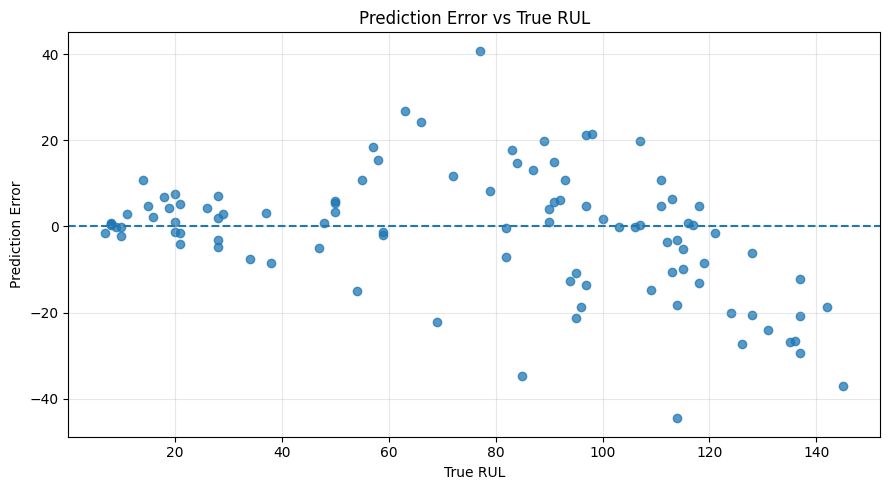

In [24]:
plt.figure(figsize=(9, 5))
plt.scatter(y_true, errors, alpha=0.75)
plt.axhline(0, linestyle="--")

plt.xlabel("True RUL")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs True RUL")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "final_error_vs_true_rul.png"), dpi=300)
plt.show()

# Distribution of Prediction Errors

The residual histogram illustrates the distribution of prediction errors across all test samples.

Most residuals are centered near zero, indicating that the model does not exhibit severe systematic bias.

The distribution also shows the presence of larger errors for certain samples, particularly at high RUL values where degradation patterns are less distinct.

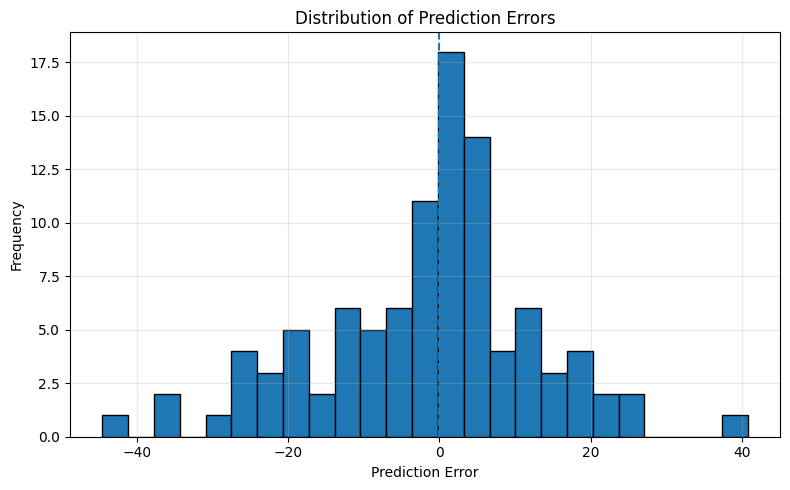

In [25]:
plt.figure(figsize=(8, 5))
plt.hist(errors, bins=25, edgecolor="black")

plt.axvline(0, linestyle="--")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "final_residual_histogram.png"), dpi=300)
plt.show()

# Sorted True vs Predicted RUL

The test samples are sorted by true RUL to better visualize the relationship between predicted and actual values.

The predicted curve generally follows the shape of the true RUL curve, confirming that the model captures the overall degradation trend effectively.

Prediction deviations become more noticeable at large RUL values, again highlighting the difficulty of modeling early-life engine behavior.

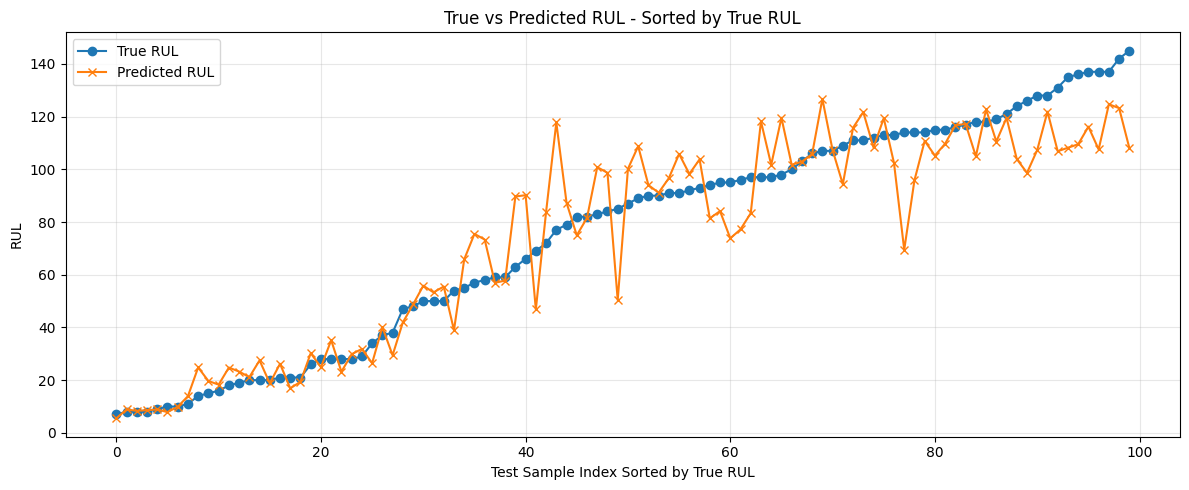

In [26]:
sorted_idx = np.argsort(y_true)

plt.figure(figsize=(12, 5))
plt.plot(y_true[sorted_idx], label="True RUL", marker="o")
plt.plot(y_pred[sorted_idx], label="Predicted RUL", marker="x")

plt.xlabel("Test Sample Index Sorted by True RUL")
plt.ylabel("RUL")
plt.title("True vs Predicted RUL - Sorted by True RUL")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "final_sorted_true_vs_predicted.png"), dpi=300)
plt.show()

# RMSE Analysis by RUL Range

This analysis evaluates prediction accuracy across different RUL intervals.

Instead of using a single global RMSE value, the prediction errors are grouped according to the true RUL range.

This provides additional insight into which operational stages are easier or harder to predict.

In [27]:
bins = [0, 25, 50, 75, 100, 125, 200]
labels = ["0-25", "25-50", "50-75", "75-100", "100-125", "125+"]

pred_df["rul_range"] = pd.cut(
    pred_df["true_rul"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

range_metrics = []

for rul_range, group in pred_df.groupby("rul_range", observed=False):
    if len(group) == 0:
        continue

    rmse_range = np.sqrt(
        mean_squared_error(group["true_rul"], group["predicted_rul"])
    )
    mae_range = mean_absolute_error(
        group["true_rul"],
        group["predicted_rul"]
    )

    range_metrics.append({
        "rul_range": rul_range,
        "samples": len(group),
        "rmse": rmse_range,
        "mae": mae_range
    })

range_metrics_df = pd.DataFrame(range_metrics)

range_metrics_df

,rul_range,samples,rmse,mae
0,0-25,19,4.171288,3.063251
1,25-50,14,5.037417,4.548834
2,50-75,10,16.899359,14.787060
3,75-100,24,16.712798,13.561707
4,100-125,22,13.531939,9.134689
5,125+,11,24.089534,22.713430


# Prediction Accuracy Across Degradation Stages

The results show that prediction accuracy is generally better for low and medium RUL ranges.

As the true RUL increases, prediction difficulty also increases due to the weaker degradation signatures present in early-life engine operation.

This behavior is consistent with the characteristics of the CMAPSS dataset and is commonly reported in predictive maintenance literature.

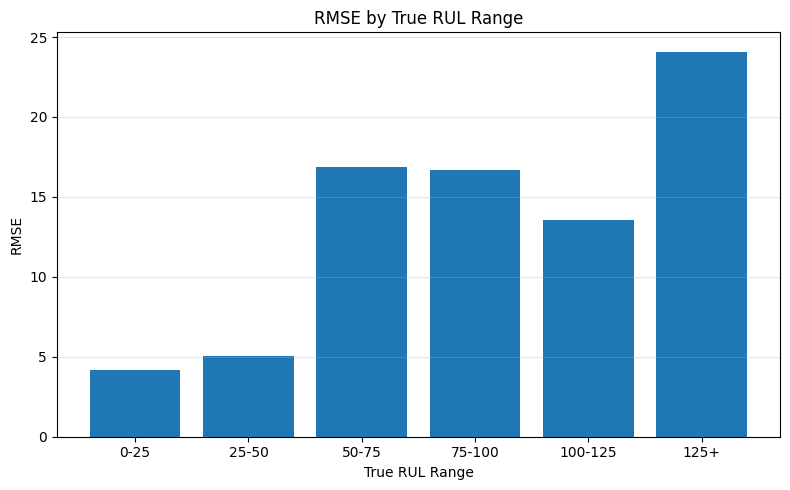

In [28]:
plt.figure(figsize=(8, 5))
plt.bar(range_metrics_df["rul_range"].astype(str), range_metrics_df["rmse"])

plt.xlabel("True RUL Range")
plt.ylabel("RMSE")
plt.title("RMSE by True RUL Range")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "rmse_by_rul_range.png"), dpi=300)
plt.show()

In [29]:
df.to_csv(os.path.join(RESULTS_DIR, "final_rul_experiment_comparison.csv"), index=False)
best_summary.to_csv(os.path.join(RESULTS_DIR, "best_model_summary.csv"), index=False)
range_metrics_df.to_csv(os.path.join(RESULTS_DIR, "rmse_by_rul_range.csv"), index=False)

# Final Conclusions

The experimental analysis demonstrated that the LSTM architecture combined with:
- a sequence length of 30,
- a RUL cap of 125,
- engine-based validation,
- and standard MSE loss

produced the best overall performance for RUL prediction on the CMAPSS FD001 dataset.

The study also showed that:
- moderate sequence lengths provide the best temporal representation,
- excessively large RUL caps reduce prediction stability,
- engine-based validation offers realistic generalization evaluation,
- and recurrent neural networks can effectively model degradation trajectories.

The prediction analysis revealed that the model performs best near failure regions where degradation signatures become more pronounced, while high RUL regions remain more challenging due to the lack of strong degradation patterns.

Overall, the results confirm the effectiveness of recurrent neural networks for predictive maintenance and Remaining Useful Life estimation in turbofan engine degradation scenarios.